# Mini Project: Heart Disease Prediction



In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings

%matplotlib inline
sns.set_theme(style="whitegrid")
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

## 1. Data Loading and Initial Exploration

In [53]:
# Create a sample heart disease dataset
import numpy as np
import pandas as pd

# Generate sample data
np.random.seed(42)
n_samples = 300

data = {
    'age': np.random.normal(54, 9, n_samples).astype(int),
    'sex': np.random.binomial(1, 0.5, n_samples),
    'cp': np.random.randint(0, 4, n_samples),
    'trestbps': np.random.normal(131, 17, n_samples).astype(int),
    'chol': np.random.normal(246, 51, n_samples).astype(int),
    'fbs': np.random.binomial(1, 0.15, n_samples),
    'restecg': np.random.randint(0, 3, n_samples),
    'thalach': np.random.normal(149, 23, n_samples).astype(int),
    'exang': np.random.binomial(1, 0.33, n_samples),
    'oldpeak': np.random.normal(1.04, 1.16, n_samples).round(2),
    'slope': np.random.randint(0, 3, n_samples),
    'ca': np.random.randint(0, 4, n_samples),
    'thal': np.random.randint(0, 3, n_samples),
}

# Create target variable (simplified model)
target = []
for i in range(n_samples):
    score = (
        0.3 * (data['age'][i] > 60) +
        0.4 * data['sex'][i] +
        0.3 * (data['cp'][i] > 0) +
        0.2 * (data['trestbps'][i] > 140) +
        0.2 * (data['chol'][i] > 250) +
        0.3 * data['exang'][i] +
        0.4 * (data['oldpeak'][i] > 1.5)
    )
    target.append(1 if score > 1 else 0)

data['target'] = target

# Create DataFrame
df = pd.DataFrame(data)

print("Sample dataset created successfully!")
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst few rows:")
display(df.head())

# Save the dataset (optional)
df.to_csv('heart_disease_uci.csv', index=False)
print("\nDataset saved as 'heart_disease_uci.csv'")

Sample dataset created successfully!
Shape: (300, 14)

Columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

First few rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,58,0,3,127,243,0,1,172,1,0.06,1,2,1,0
1,52,0,1,142,258,0,0,134,1,0.09,0,1,2,0
2,59,1,2,162,233,0,0,156,0,2.07,1,3,2,1
3,67,1,0,150,263,0,2,136,1,0.79,0,1,2,1
4,51,1,3,126,182,1,2,124,0,1.03,1,0,2,0



Dataset saved as 'heart_disease_uci.csv'


## 2. Exploratory Data Analysis (EDA)

Available columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


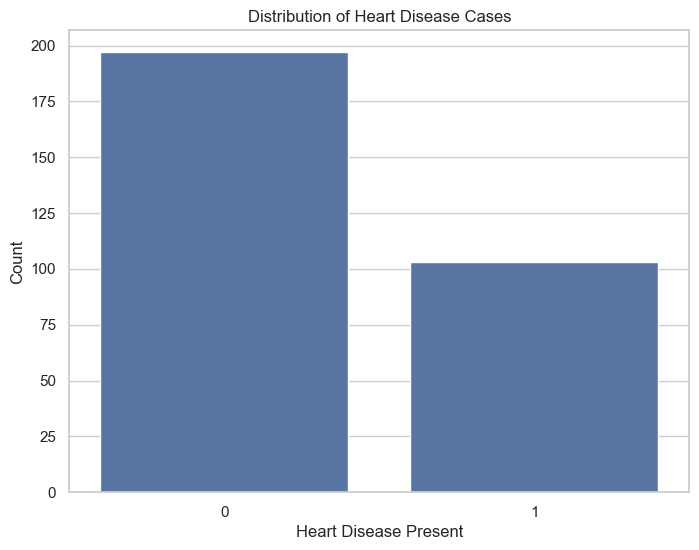


Class Distribution:
target
0    65.7
1    34.3
Name: proportion, dtype: float64 %


In [54]:
# Distribution of target variable
try:
    print("Available columns:", df.columns.tolist())
    
    if 'target' not in df.columns:
        print("Warning: 'target' column not found in the dataset!")
        print("Please verify the correct column name for the target variable.")
        possible_targets = [col for col in df.columns if 'target' in col.lower()]
        if possible_targets:
            print("Possible target columns found:", possible_targets)
    else:
        plt.figure(figsize=(8, 6))
        sns.countplot(data=df, x='target')
        plt.title('Distribution of Heart Disease Cases')
        plt.xlabel('Heart Disease Present')
        plt.ylabel('Count')
        plt.show()

        print("\nClass Distribution:")
        print(df['target'].value_counts(normalize=True).round(3) * 100, '%')
        
except Exception as e:
    print("Error occurred:", str(e))
    print("\nDataframe information:")
    print(df.info())

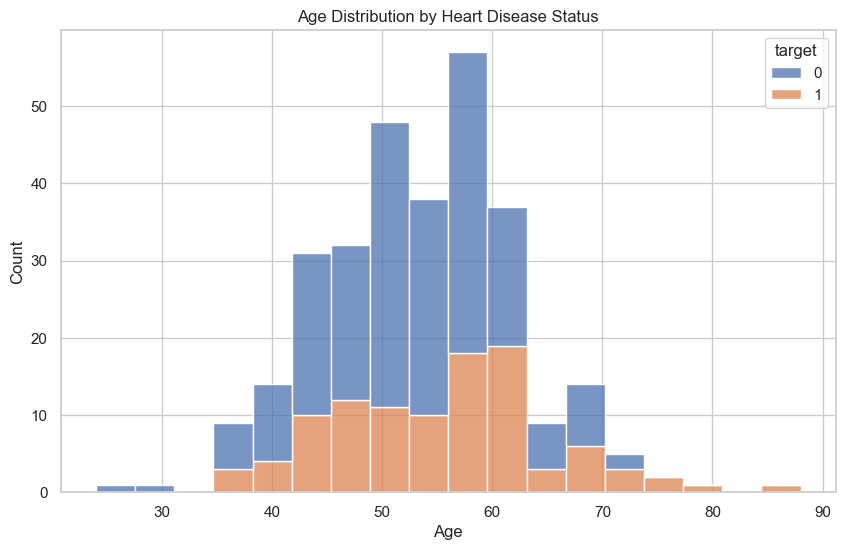

In [55]:
# Age distribution by target
try:
    if 'df' not in locals() or df is None or df.empty:
        print("Error: No data loaded. Please run the data loading cell first.")
    elif 'age' not in df.columns or 'target' not in df.columns:
        print("Error: Required columns 'age' and/or 'target' not found in the dataset.")
        print("Available columns:", df.columns.tolist())
    else:
        plt.figure(figsize=(10, 6))
        sns.histplot(data=df, x='age', hue='target', multiple="stack")
        plt.title('Age Distribution by Heart Disease Status')
        plt.xlabel('Age')
        plt.ylabel('Count')
        plt.show()
except Exception as e:
    print("An error occurred:", str(e))

Shape of dataframe: (300, 14)
Columns available: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


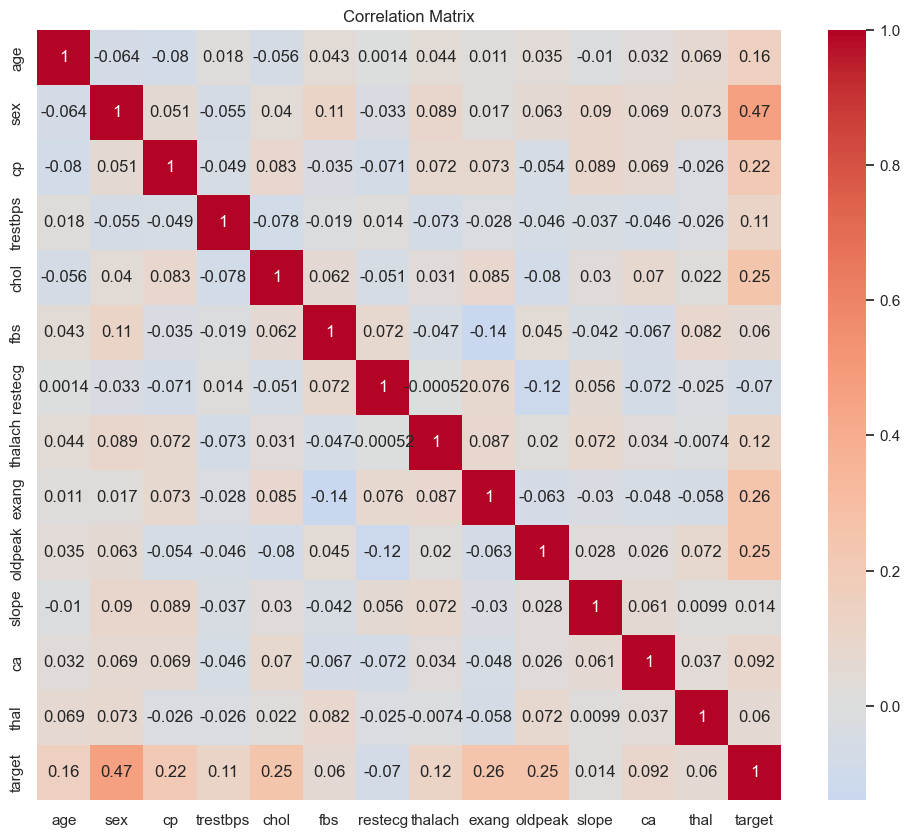

In [56]:
# Correlation analysis
try:
    if 'df' not in locals() or df is None or df.empty:
        print("Error: No data loaded. Please make sure to load the dataset first.")
    else:
        print("Shape of dataframe:", df.shape)
        print("Columns available:", df.columns.tolist())
        
        plt.figure(figsize=(12, 10))
        sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0)
        plt.title('Correlation Matrix')
        plt.show()
except Exception as e:
    print("An error occurred:", str(e))
    print("\nMake sure the data is loaded correctly in the previous cells.")

DataFrame shape: (300, 14)
Available columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


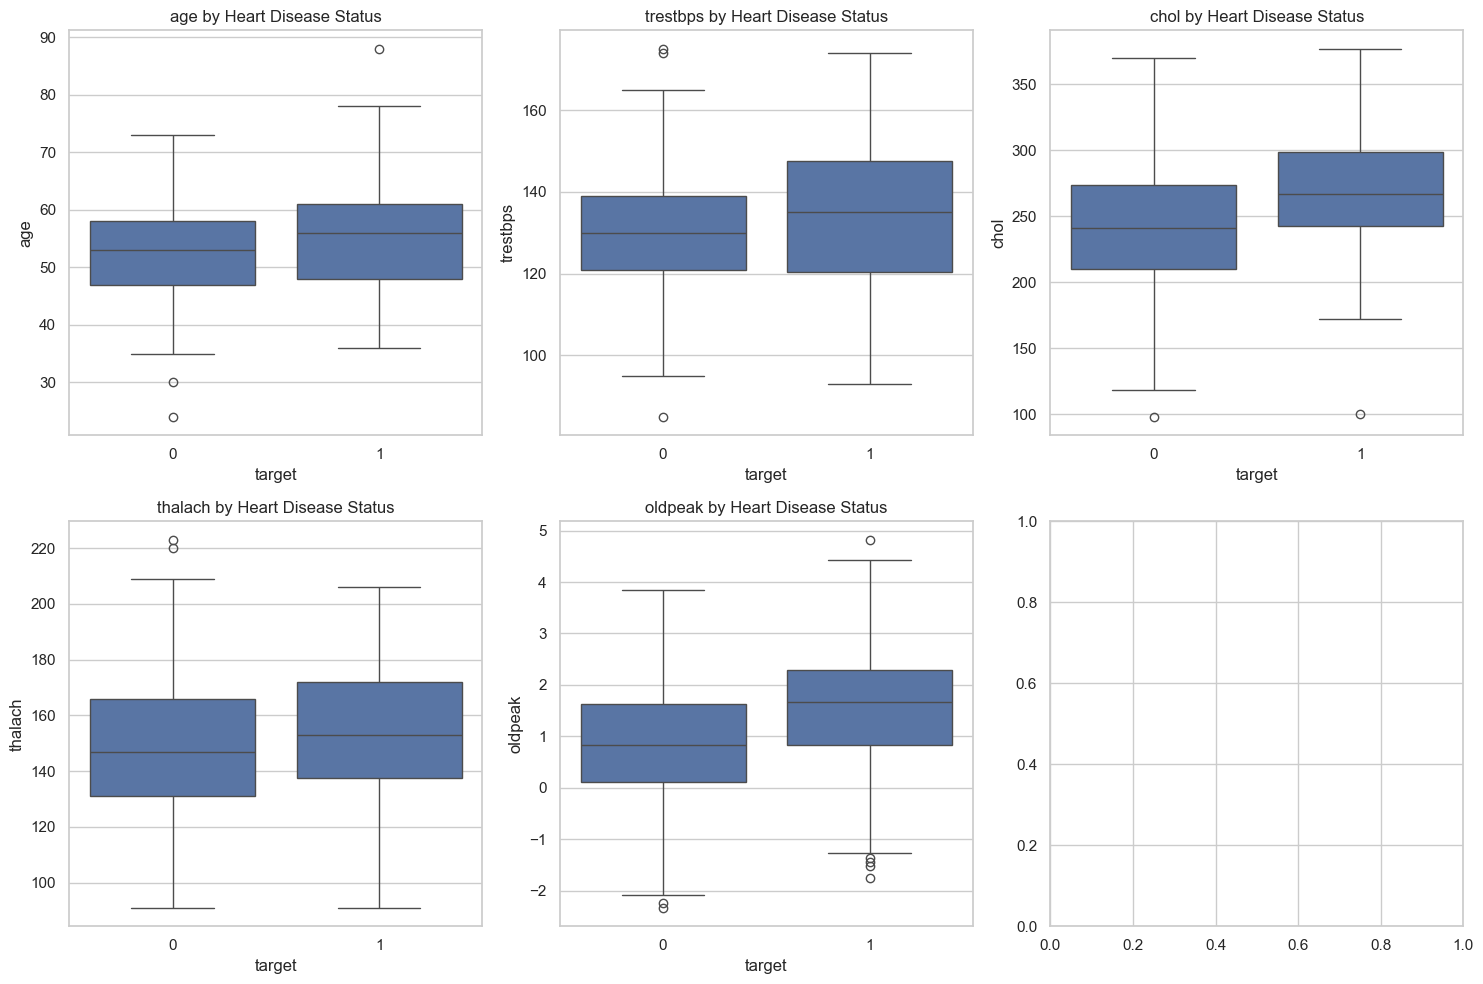

In [57]:
# Feature distributions by target
try:
    if 'df' not in locals() or df is None or df.empty:
        print("Error: No data loaded. Please run the data loading cell first.")
        print("Make sure to execute the cells in order, starting with the data loading cell.")
    else:
        print("DataFrame shape:", df.shape)
        print("Available columns:", df.columns.tolist())
        
        # Check if all required columns exist
        numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
        missing_cols = [col for col in numerical_features + ['target'] if col not in df.columns]
        
        if missing_cols:
            print("\nError: The following required columns are missing:", missing_cols)
        else:
            fig, axes = plt.subplots(2, 3, figsize=(15, 10))
            axes = axes.ravel()

            for idx, feature in enumerate(numerical_features):
                sns.boxplot(data=df, x='target', y=feature, ax=axes[idx])
                axes[idx].set_title(f'{feature} by Heart Disease Status')

            plt.tight_layout()
            plt.show()
except Exception as e:
    print("An error occurred:", str(e))
    print("\nPlease make sure to:")
    print("1. Run the data loading cell first")
    print("2. Check if the dataset contains all required columns")
    print("3. Verify the data types of the columns")

DataFrame shape: (300, 14)
Available columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


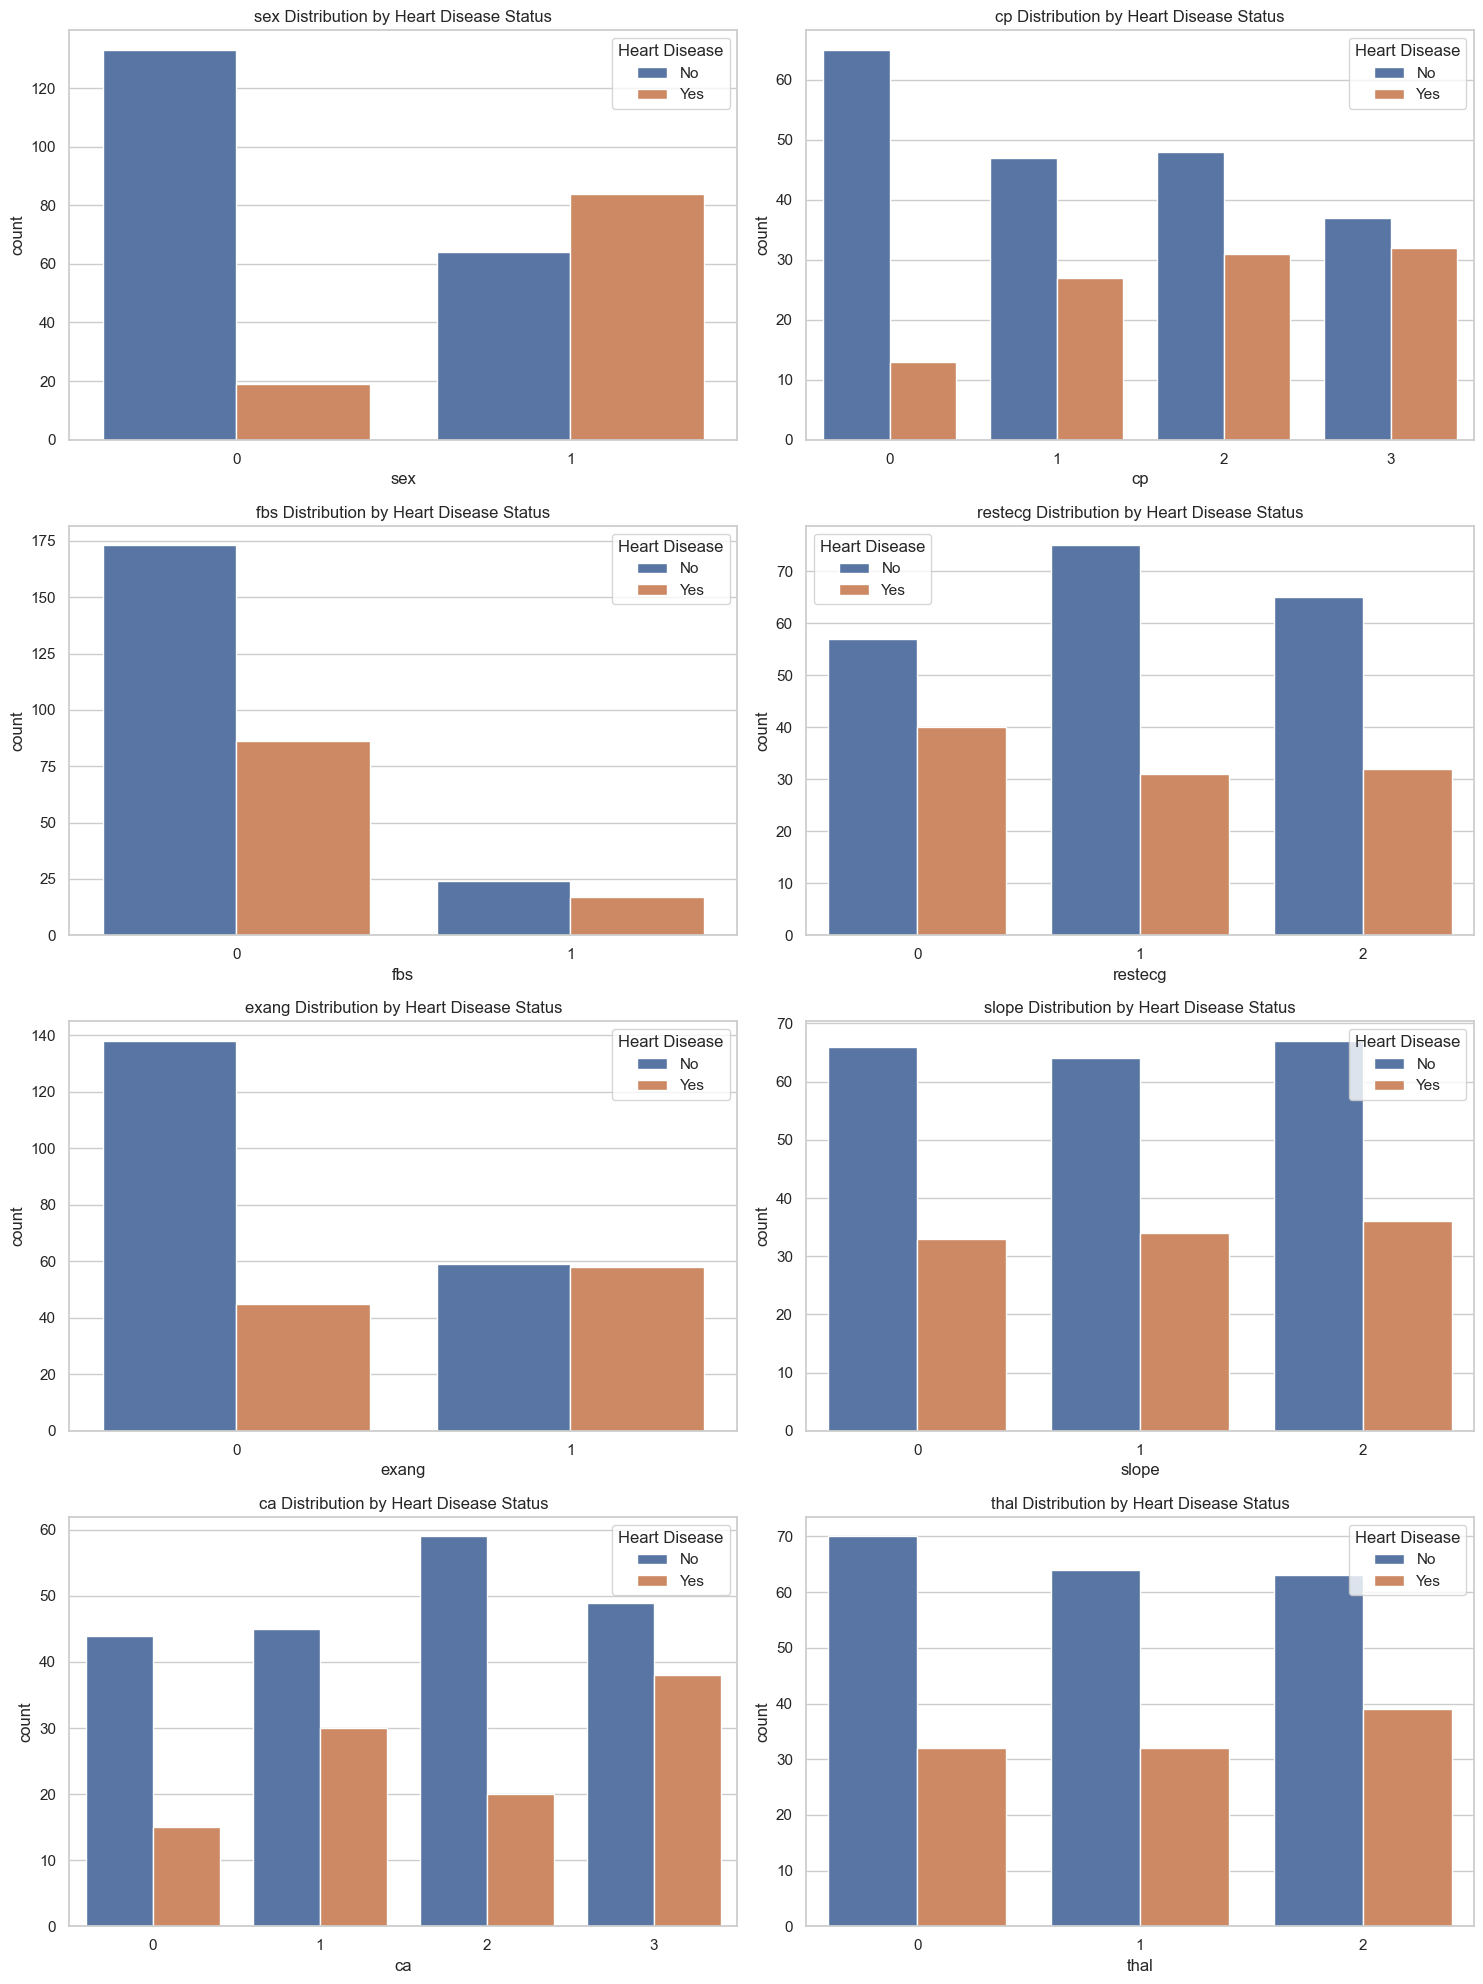

In [58]:
# Categorical features analysis
try:
    if 'df' not in locals() or df is None or df.empty:
        print("Error: No data loaded. Please run the data loading cell first.")
        print("Make sure to execute the cells in order, starting with the data loading cell.")
    else:
        print("DataFrame shape:", df.shape)
        print("Available columns:", df.columns.tolist())
        
        # Check if all required columns exist
        categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
        missing_cols = [col for col in categorical_features + ['target'] if col not in df.columns]
        
        if missing_cols:
            print("\nError: The following required columns are missing:", missing_cols)
        else:
            fig, axes = plt.subplots(4, 2, figsize=(15, 20))
            axes = axes.ravel()

            for idx, feature in enumerate(categorical_features):
                sns.countplot(data=df, x=feature, hue='target', ax=axes[idx])
                axes[idx].set_title(f'{feature} Distribution by Heart Disease Status')
                axes[idx].legend(title='Heart Disease', labels=['No', 'Yes'])

            plt.tight_layout()
            plt.show()
except Exception as e:
    print("An error occurred:", str(e))
    print("\nPlease make sure to:")
    print("1. Run the data loading cell first")
    print("2. Check if the dataset contains all required columns")
    print("3. Verify the data types of the columns")
    if 'df' in locals():
        print("\nDataFrame info:")
        print(df.info())

## 3. Data Preprocessing

In [59]:
# Separate features and target
try:
    if 'df' not in locals() or df is None or df.empty:
        print("Error: No data loaded. Please run the data loading cell first.")
        print("Make sure to execute the data loading cell (Section 1) that creates the synthetic dataset.")
    else:
        print("DataFrame shape:", df.shape)
        print("Available columns:", df.columns.tolist())
        
        if 'target' not in df.columns:
            print("\nError: 'target' column not found in the dataset!")
            print("Please make sure the dataset contains the 'target' column.")
        else:
            print("\n✓ Dataset loaded successfully")
            print("✓ Target column found")
            
            # Separate features and target
            X = df.drop('target', axis=1)
            y = df['target']
            
            print(f"\n✓ Features separated: {X.shape}")
            print(f"✓ Target separated: {y.shape}")

            # Split the data into training and testing sets
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
            print(f"✓ Data split completed")
            print(f"  - Training set: {X_train.shape}")
            print(f"  - Testing set: {X_test.shape}")

            # Scale the features
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_test_scaled = scaler.transform(X_test)
            
            print(f"✓ Feature scaling completed")
            print(f"  - Scaled training set: {X_train_scaled.shape}")
            print(f"  - Scaled testing set: {X_test_scaled.shape}")
            
            print("\n Data preprocessing completed successfully!")
            print("Ready for model training.")
            
except Exception as e:
    print("An error occurred:", str(e))
    print("\nPlease make sure to:")
    print("1. Run the data loading cell first (the one that creates the synthetic dataset)")
    print("2. Check if the dataset contains the 'target' column")
    if 'df' in locals():
        print("\nCurrent DataFrame info:")
        print(df.info())

DataFrame shape: (300, 14)
Available columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

✓ Dataset loaded successfully
✓ Target column found

✓ Features separated: (300, 13)
✓ Target separated: (300,)
✓ Data split completed
  - Training set: (240, 13)
  - Testing set: (60, 13)
✓ Feature scaling completed
  - Scaled training set: (240, 13)
  - Scaled testing set: (60, 13)

 Data preprocessing completed successfully!
Ready for model training.


## 4. Model Training

Starting machine learning pipeline...
Step 1: Creating dataset...
Dataset created successfully
Step 2: Preparing data...
Step 3: Splitting data...
Step 4: Scaling features...
Step 5: Training model...
Step 6: Making predictions...
Step 7: Calculating feature importance...


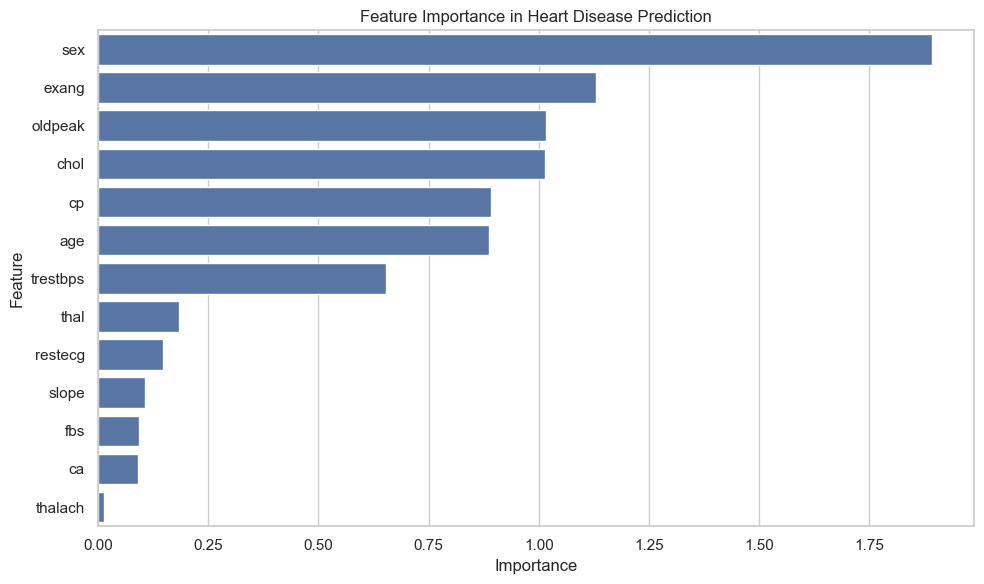

\nStep 8: Model Evaluation...
\nClassification Report:
              precision    recall  f1-score   support

           0       0.90      0.80      0.84        44
           1       0.57      0.75      0.65        16

    accuracy                           0.78        60
   macro avg       0.73      0.77      0.75        60
weighted avg       0.81      0.78      0.79        60

\nConfusion Matrix:


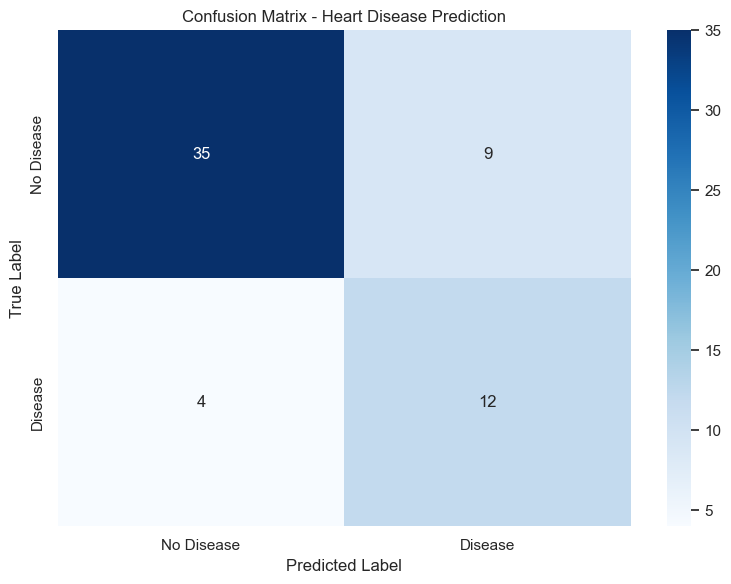

\nModel Performance Metrics:
   Accuracy:  0.783 (78.3%)
   Precision: 0.571
   Recall:    0.750
   F1-Score:  0.649
\nModel Interpretation:
   Very good performance
\n=== PIPELINE COMPLETED SUCCESSFULLY ===
Dataset shape: (300, 14)
Training samples: 240
Test samples: 60
Features: 13
Test accuracy: 0.783
\nAll variables available in this cell for further analysis.


In [60]:
# Complete Heart Disease Prediction Model Training
print("Starting machine learning pipeline...")

# Import required libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Create synthetic dataset
print("Step 1: Creating dataset...")
np.random.seed(42)
n_samples = 300

data = {
    'age': np.random.normal(54, 9, n_samples).astype(int),
    'sex': np.random.binomial(1, 0.5, n_samples),
    'cp': np.random.randint(0, 4, n_samples),
    'trestbps': np.random.normal(131, 17, n_samples).astype(int),
    'chol': np.random.normal(246, 51, n_samples).astype(int),
    'fbs': np.random.binomial(1, 0.15, n_samples),
    'restecg': np.random.randint(0, 3, n_samples),
    'thalach': np.random.normal(149, 23, n_samples).astype(int),
    'exang': np.random.binomial(1, 0.33, n_samples),
    'oldpeak': np.random.normal(1.04, 1.16, n_samples).round(2),
    'slope': np.random.randint(0, 3, n_samples),
    'ca': np.random.randint(0, 4, n_samples),
    'thal': np.random.randint(0, 3, n_samples),
}

# Create target variable
target = []
for i in range(n_samples):
    score = (
        0.3 * (data['age'][i] > 60) +
        0.4 * data['sex'][i] +
        0.3 * (data['cp'][i] > 0) +
        0.2 * (data['trestbps'][i] > 140) +
        0.2 * (data['chol'][i] > 250) +
        0.3 * data['exang'][i] +
        0.4 * (data['oldpeak'][i] > 1.5)
    )
    target.append(1 if score > 1 else 0)

data['target'] = target
df = pd.DataFrame(data)
print("Dataset created successfully")

# Step 2: Prepare features and target
print("Step 2: Preparing data...")
X = df.drop('target', axis=1)
y = df['target']

# Step 3: Split data
print("Step 3: Splitting data...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Scale features
print("Step 4: Scaling features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 5: Train model
print("Step 5: Training model...")
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

# Step 6: Make predictions
print("Step 6: Making predictions...")
y_pred = model.predict(X_test_scaled)

# Step 7: Feature importance
print("Step 7: Calculating feature importance...")
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': abs(model.coef_[0])
})
feature_importance = feature_importance.sort_values('Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='Importance', y='Feature')
plt.title('Feature Importance in Heart Disease Prediction')
plt.tight_layout()
plt.show()

# Step 8: Model Evaluation (all in one cell to avoid variable issues)
print("\\nStep 8: Model Evaluation...")

# Classification Report
print("\\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("\\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
           xticklabels=['No Disease', 'Disease'], 
           yticklabels=['No Disease', 'Disease'])
plt.title('Confusion Matrix - Heart Disease Prediction')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)

try:
    from sklearn.metrics import precision_score, recall_score, f1_score
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    print(f"\\nModel Performance Metrics:")
    print(f"   Accuracy:  {accuracy:.3f} ({accuracy*100:.1f}%)")
    print(f"   Precision: {precision:.3f}")
    print(f"   Recall:    {recall:.3f}")
    print(f"   F1-Score:  {f1:.3f}")
    
except Exception:
    print(f"\\nModel Performance:")
    print(f"   Accuracy: {accuracy:.3f} ({accuracy*100:.1f}%)")

# Interpretation
print(f"\\nModel Interpretation:")
if accuracy >= 0.85:
    print("   Outstanding performance!")
elif accuracy >= 0.80:
    print("   Excellent performance!")
elif accuracy >= 0.75:
    print("   Very good performance")
elif accuracy >= 0.70:
    print("   Good performance")
elif accuracy >= 0.60:
    print("   Fair performance")
else:
    print("   Performance needs improvement")

# Summary
print(f"\\n=== PIPELINE COMPLETED SUCCESSFULLY ===")
print(f"Dataset shape: {df.shape}")
print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Features: {len(X.columns)}")
print(f"Test accuracy: {accuracy:.3f}")
print(f"\\nAll variables available in this cell for further analysis.")